In [45]:
import roman 
import numpy as np 


import pandas as pd 
from matplotlib.lines import Line2D
from Bio.SeqFeature import FeatureLocation
from pandas.api.types import CategoricalDtype

In [46]:
def get_format_table(CSV_file, snps_loc):
    qtl_res = pd.read_table(CSV_file)
    qtl_res = qtl_res.merge(snps_loc, on='SNP')
    qtl_res = qtl_res.rename(columns={'gene':'Condition'})
    # qtl_res['lod-value'] = [ calculate_lod(qtl_res, i, nb_strains) for i in range(len(qtl_res)) ]
    return qtl_res


def format_roman_chrom(x):
    if 'MT' not in x : 
        rom_nb = x.replace('chr','')
        nb = roman.fromRoman(rom_nb)
        x = int(nb)
        return x 
    return x

In [47]:
### Inputs
#### Genotype matrix
genotype_matrix = pd.read_csv('../../../data/genotype_information/piQTL_genotype_matrix_dec2022.txt')  
nb_strains = len(genotype_matrix.columns) - 1

#### LD blocks
LD_table = pd.read_csv('../../../scripts/01_experimental_checks/LD_table.csv')
LD_table = LD_table.set_index('SNP')

LD_blocks = pd.read_csv('../../../data/genome_annotations/LD_blocks_0.5_annotations.csv')

#### Gene annotations
gene_annotations = pd.read_csv('../../../data/genome_annotations/sgd_database/orf_coding_R64-3-1.csv').rename(columns={"name":"Gene", "chrom":"Chrom", "start":"Start", "end":"End", "genome_annotations":"Coding"}) 
gene_annotations.to_csv('../../../data/zoomlocus_inputs/yeast_genes.txt', index=False)

#### Snps annotations
snps_annotations = pd.read_csv('../../../data/genotype_information/snps_annotations_genome-version-3-64-1_with_gene_annotations_plus_LD_block_definition.txt')
snps_annotations['CHR'] = [int(snps_annotations['chrom'][idx].replace('MT','17').replace('CHR_', '')) for idx in snps_annotations.index ]

In [48]:
## Remove noPPI_reference + FDR filter (0.05)

def get_PPI_spe_SNPs(idx, piQTLs_PPI_specific_ublocks_to_mask):
    PPI = piQTLs_PPI_specific_ublocks_to_mask['PPI'][idx]
    ublock = piQTLs_PPI_specific_ublocks_to_mask['LD_b075'][idx]

    PPI_SNPs = []
    for SNP in ublock.split('_') :
        PPI_SNPs.append(f'{PPI}_{SNP}')
    return ','.join(PPI_SNPs)

def has_PPI_SNP(idx, table, PPI_SNPs_list):
    PPI_SNPs = table['PPI_SNPs'][idx]
    for PPI_SNP in PPI_SNPs.split(','):
            if PPI_SNP in PPI_SNPs_list:
                return True
            else :
                return False

def get_piQTL_final_table(piQTLs_PPI_specific_SNPs_to_mask, all_SNPs_to_mask):
    eqtl_matrix_results = pd.read_csv('../../../results/04_eQTL_matrix/piQTL_june2024_pval_results.txt', sep='\t')
    piQTLs_fdr_filtered = eqtl_matrix_results[~(eqtl_matrix_results['gene'].str.contains('noPPI_reference')) & (eqtl_matrix_results['FDR'] < 0.05)].reset_index(drop=True)
    piQTLs_fdr_filtered['PPI'] = [ f"{piQTLs_fdr_filtered['gene'][idx].split('_')[0]}_{piQTLs_fdr_filtered['gene'][idx].split('_')[1]}" for idx in piQTLs_fdr_filtered.index ]
    piQTLs_fdr_filtered['DRUG'] = [ piQTLs_fdr_filtered['gene'][idx].split('_')[3] for idx in piQTLs_fdr_filtered.index ]
    piQTLs_fdr_filtered['-log10_P'] = - np.log10(piQTLs_fdr_filtered['p-value'])

    piQTLs_fdr_filtered = piQTLs_fdr_filtered.merge(snps_annotations, on='SNP')
    piQTLs_fdr_filtered['PPI_block'] = [ f"{piQTLs_fdr_filtered['PPI'][idx]}-{piQTLs_fdr_filtered['LD_b050'][idx]}" for idx in piQTLs_fdr_filtered.index ]
    piQTLs_fdr_filtered['PPI_lead_SNP'] = [ f"{piQTLs_fdr_filtered['PPI'][idx]}-{piQTLs_fdr_filtered['SNP'][idx]}" for idx in piQTLs_fdr_filtered.index ]
    piQTLs_fdr_filtered['PPI_SNPs'] = [ get_PPI_spe_SNPs(idx, piQTLs_fdr_filtered) for idx in piQTLs_fdr_filtered.index ]
    piQTLs_fdr_filtered['has_PPI_SNP'] = [ has_PPI_SNP(idx, piQTLs_fdr_filtered, piQTLs_PPI_specific_SNPs_to_mask) for idx in piQTLs_fdr_filtered.index ]

    # all_SNPs_to_exclude = [ SNP for SNP_list in [MTX_reported_SNPs, QTLs_media_untagged_SNPs_full_list, other_SNPs_to_exclude] for SNP in SNP_list ]
    piQTLs_with_MTX_masking = piQTLs_fdr_filtered[~piQTLs_fdr_filtered['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)
    piQTLs_with_MTX_and_media_masking = piQTLs_with_MTX_masking[piQTLs_with_MTX_masking['has_PPI_SNP'] == False].reset_index(drop=True)

    final_piQTLs_with_MTX_and_media_masking = piQTLs_with_MTX_and_media_masking.sort_values('-log10_P', ascending=False).drop_duplicates(subset=['PPI','DRUG','LD_b050'], keep='first').reset_index(drop=True)
    return final_piQTLs_with_MTX_and_media_masking


In [49]:
## QTL media (SD only and PPI specific) 
f = open('../../../data/masking_tables/QTL_masked_hits.txt')
piQTLs_untagged_ublocks_to_mask = [ line.strip() for line in f.readlines() ]
f.close()

all_SNPs_to_mask = []
for ublock in piQTLs_untagged_ublocks_to_mask: 
    if '_' not in ublock :
        SNP = ublock
        all_SNPs_to_mask.append(int(SNP))
    else : 
        SNPs = ublock.split('_')
        for SNP in SNPs:
            all_SNPs_to_mask.append(int(SNP))

piQTLs_PPI_specific_ublocks_to_mask = pd.read_csv('../../../data/masking_tables/QTL_media_PPI-specific_all_hits.csv')
piQTLs_PPI_specific_SNPs_to_mask = []
for idx in piQTLs_PPI_specific_ublocks_to_mask.index:
    PPI_SNPs = get_PPI_spe_SNPs(idx, piQTLs_PPI_specific_ublocks_to_mask) 
    for SNP in PPI_SNPs.split(','):
        piQTLs_PPI_specific_SNPs_to_mask.append(SNP)

In [50]:
final_piQTLs = get_piQTL_final_table(piQTLs_PPI_specific_SNPs_to_mask, all_SNPs_to_mask)

In [51]:
final_piQTLs.sort_values('-log10_P', ascending=False)

,SNP,gene,beta,t-stat,p-value,FDR,PPI,DRUG,-log10_P,chrom,...,LD_b075,LD_b050,is_in_gene,gene_locus,gene_name,CHR,PPI_block,PPI_lead_SNP,PPI_SNPs,has_PPI_SNP
0,8799,ERG11_ORM2_MTX_Metformin_avg_logratio_Fitness_...,0.412412,5.955680,6.232370e-09,0.000003,ERG11_ORM2,Metformin,8.205347,CHR_13,...,8799_8800,8797_8798_8799_8800_8801_8802_8803_8804_8805_8...,True,YMR113W,FOL3,13,ERG11_ORM2-8797_8798_8799_8800_8801_8802_8803_...,ERG11_ORM2-8799,"ERG11_ORM2_8799,ERG11_ORM2_8800",False
1,10438,SSH1_ORM2_MTX_noDrug_avg_logratio_Fitness_minu...,-1.424358,-5.824198,1.286408e-08,0.000006,SSH1_ORM2,noDrug,7.890621,CHR_15,...,10438_10439,10438_10439_10440_10441,True,YOR065W,CYT1,15,SSH1_ORM2-10438_10439_10440_10441,SSH1_ORM2-10438,"SSH1_ORM2_10438,SSH1_ORM2_10439",False
2,8792,ERG11_ORM2_MTX_Metformin_avg_logratio_Fitness_...,0.400424,5.759528,1.828869e-08,0.000008,ERG11_ORM2,Metformin,7.737817,CHR_13,...,8792,8749_8750_8751_8752_8753_8754_8755_8756_8757_8...,True,YMR109W,MYO5,13,ERG11_ORM2-8749_8750_8751_8752_8753_8754_8755_...,ERG11_ORM2-8792,ERG11_ORM2_8792,False
3,8810,ERG11_ORM2_MTX_Metformin_avg_logratio_Fitness_...,0.401647,5.665284,3.037285e-08,0.000013,ERG11_ORM2,Metformin,7.517515,CHR_13,...,8810_8811_8812_8813_8814_8815_8816_8817_8818_8...,8809_8810_8811_8812_8813_8814_8815_8816_8817_8...,False,NaN,NaN,13,ERG11_ORM2-8809_8810_8811_8812_8813_8814_8815_...,ERG11_ORM2-8810,"ERG11_ORM2_8810,ERG11_ORM2_8811,ERG11_ORM2_881...",False
4,10438,ERV25_ORM2_MTX_noDrug_avg_logratio_Fitness_min...,-1.216292,-5.546540,5.701815e-08,0.000023,ERV25_ORM2,noDrug,7.243987,CHR_15,...,10438_10439,10438_10439_10440_10441,True,YOR065W,CYT1,15,ERV25_ORM2-10438_10439_10440_10441,ERV25_ORM2-10438,"ERV25_ORM2_10438,ERV25_ORM2_10439",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,3951,ERG11_HYR1_MTX_Fluconazole_avg_logratio_Fitnes...,-0.448171,-3.747808,2.081572e-04,0.049850,ERG11_HYR1,Fluconazole,3.681609,CHR_7,...,3951,3950_3951_3952_3953_3954,True,YGL211W,NCS6,7,ERG11_HYR1-3950_3951_3952_3953_3954,ERG11_HYR1-3951,ERG11_HYR1_3951,False
1181,7430,RET2_EMP47_MTX_Fluconazole_avg_logratio_Fitnes...,1.023427,3.747496,2.084062e-04,0.049895,RET2_EMP47,Fluconazole,3.681089,CHR_12,...,7430,7430_7431_7432,True,YLL061W,MMP1,12,RET2_EMP47-7430_7431_7432,RET2_EMP47-7430,RET2_EMP47_7430,False
1182,10482,ERG11_TPO4_MTX_Fluconazole_avg_logratio_Fitnes...,-0.487098,-3.747432,2.084567e-04,0.049904,ERG11_TPO4,Fluconazole,3.680984,CHR_15,...,10482_10483,10482_10483,False,NaN,NaN,15,ERG11_TPO4-10482_10483,ERG11_TPO4-10482,"ERG11_TPO4_10482,ERG11_TPO4_10483",False
1183,9430,DHH1_LSM3_MTX_Fluconazole_avg_logratio_Fitness...,-0.582861,-3.747327,2.085409e-04,0.049921,DHH1_LSM3,Fluconazole,3.680809,CHR_14,...,9427_9428_9429_9430,9403_9404_9405_9406_9407_9408_9409_9410_9411_9...,True,YNL222W,SSU72,14,DHH1_LSM3-9403_9404_9405_9406_9407_9408_9409_9...,DHH1_LSM3-9430,"DHH1_LSM3_9427,DHH1_LSM3_9428,DHH1_LSM3_9429,D...",False


#### Unstable transcripts

In [52]:
CUT_annotations = pd.read_csv('../../../data/genome_annotations/xu_2009/Xu_2009_CUTs_V64.csv')  
CUT_annotations['seqid'] = CUT_annotations['seq_id'].apply(format_roman_chrom)

SUT_annotations = pd.read_csv('../../../data/genome_annotations/xu_2009/Xu_2009_SUTs_V64.csv')  
SUT_annotations['seqid'] = SUT_annotations['seq_id'].apply(format_roman_chrom)

XUT_annotations = pd.read_csv('../../../data/genome_annotations/van_dikj_2011/van_Dijk_2011_XUTs_V64.csv') 
XUT_annotations['seqid'] = XUT_annotations['seq_id'].apply(format_roman_chrom)

#### GWAS

In [53]:
snps_annotations

,SNP,chrom,position,REF,ALT,locus_id,name,sgd_id,description,snps_class_up,genome_annotations,snps_class_down,LD_b075,LD_b050,is_in_gene,gene_locus,gene_name,CHR
0,1,CHR_1,1025,C,T,X1L_NFR/NDR,NaN,NaN,NaN,Promoter,Promoter,Promoter,1,1_2,False,NaN,NaN,1
1,2,CHR_1,1035,A,T,X1L_NFR/NDR,NaN,NaN,NaN,Promoter,Promoter,Promoter,2,1_2,False,NaN,NaN,1
2,3,CHR_1,1074,C,A,YAL069W,YAL069W,SGDID:S000002143,"""Dubious open reading frame; unlikely to encod...",Close to 3'-UTR,Dubious ORF,Close to 3'-UTR,3,3,True,YAL069W,YAL069W,1
3,4,CHR_1,1470,A,G,YAL069W,YAL069W,SGDID:S000002143,"""Dubious open reading frame; unlikely to encod...",Close to 3'-UTR,Dubious ORF,Close to 3'-UTR,4,4,True,YAL069W,YAL069W,1
4,5,CHR_1,1475,AT,A,YAL069W,YAL069W,SGDID:S000002143,"""Dubious open reading frame; unlikely to encod...",Close to 3'-UTR,Dubious ORF,Close to 3'-UTR,5,5,True,YAL069W,YAL069W,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12049,12050,CHR_MT,74432,TG,T,Q0250,COX2,SGDID:S000007281,"""Subunit II of cytochrome c oxidase (Complex I...",Close to 3'-UTR,Verified ORF,Close to 3'-UTR,12050,12050,True,Q0250,COX2,17
12050,12051,CHR_MT,74433,G,GGACTA,Q0250,COX2,SGDID:S000007281,"""Subunit II of cytochrome c oxidase (Complex I...",Close to 3'-UTR,Verified ORF,Close to 3'-UTR,12051,12051,True,Q0250,COX2,17
12051,12052,CHR_MT,77708,T,"A,G",Q:77506-78088,NaN,NaN,between YNCQ0023W and YNCQ0024C,Intergenic region,Intergenic region,Intergenic region,12052,12052,False,NaN,NaN,17
12052,12053,CHR_MT,84245,G,"GCC,GTC",Q:82601-85034,NaN,NaN,between ORI5 and YNCQ0026W,Intergenic region,Intergenic region,Intergenic region,12053_12054,12053_12054,False,NaN,NaN,17


In [54]:
all_GWAS_Fluconazole = get_format_table('../../../results/10_gwas_results/Fluconazole_pval_results.txt', snps_annotations) 
GWAS_Fluconazole_36H = all_GWAS_Fluconazole[all_GWAS_Fluconazole['Condition'] == '36h-Fluconazole'].reset_index(drop=True)
GWAS_Fluconazole_36H = GWAS_Fluconazole_36H.rename(columns={'beta':'EFFECTSIZE', 'p-value':'P', 'position':'BP', 'name':'GENE'})
GWAS_Fluconazole_36H.to_csv('../../../data/zoomlocus_inputs/GWAS_Fluconazole_36H.txt', index=False)

all_GWAS_Fluconazole = get_format_table('../../../results/10_gwas_results/Fluconazole_pval_results_full_GWAS.txt', snps_annotations)  
GWAS_Fluconazole_36H_full = all_GWAS_Fluconazole[all_GWAS_Fluconazole['Condition'] == '36h-Fluconazole'].reset_index(drop=True)
GWAS_Fluconazole_36H_full = GWAS_Fluconazole_36H_full.rename(columns={'beta':'EFFECTSIZE', 'p-value':'P', 'position':'BP', 'name':'GENE'})
GWAS_Fluconazole_36H_full.to_csv('../../../data/zoomlocus_inputs/GWAS_Fluconazole_36H_full_GWAS.txt', index=False)

In [55]:
chr_order = CategoricalDtype(
    ['CHR_1', 
    'CHR_2', 
    'CHR_3', 
    'CHR_4', 
    'CHR_5', 
    'CHR_6', 
    'CHR_7', 
    'CHR_8', 
    'CHR_9', 
    'CHR_10', 
    'CHR_11', 
    'CHR_12', 
    'CHR_13', 
    'CHR_14', 
    'CHR_15', 
    'CHR_16', 
    'CHR_MT'], 
    ordered=True
)

def get_chr_limits(snp_position):
    #### Delimitations of chromosomes based on SNPs index
    chr_limits = []
    for chr in np.unique(snp_position['chrom'].values):
        TMP = snp_position[snp_position['chrom'] == chr]
        chr_limits.append([chr, int(TMP['snp_id'].describe()['min']), int(TMP['snp_id'].describe()['max']), int(TMP['position'].describe()['min']), int(TMP['position'].describe()['max'])])
    chr_limit_table = pd.DataFrame(chr_limits, columns=['CHR', 'SNP_IDX_FIRST', 'SNP_IDX_LAST', 'SNP_POS_FIRST', 'SNP_POS_LAST']).sort_values('SNP_IDX_FIRST')
    chr_limit_table['CHR'] = chr_limit_table['CHR'].astype(chr_order)
    print(chr_limit_table)
    return chr_limit_table

In [56]:
snp_position = pd.read_csv('../../../data/genotype_information/snps_annotations_genome-version-3-64-1.txt')
chr_limits = get_chr_limits(snp_position)
chr_limits['CHR_SIZE'] = chr_limits['SNP_POS_LAST'] - chr_limits['SNP_POS_FIRST']

       CHR  SNP_IDX_FIRST  SNP_IDX_LAST  SNP_POS_FIRST  SNP_POS_LAST
0    CHR_1              1           181           1025        223059
8    CHR_2            182           886           7366        804707
9    CHR_3            887          1252            450        316065
10   CHR_4           1253          2767           2228       1523587
11   CHR_5           2768          3590           8786        566755
12   CHR_6           3591          3856          12139        270132
13   CHR_7           3857          4841            331       1073937
14   CHR_8           4842          5434          13662        556515
15   CHR_9           5435          5982          19515        437999
1   CHR_10           5983          6599          26272        745651
2   CHR_11           6600          7419            833        666544
3   CHR_12           7420          8410          11408       1062523
4   CHR_13           8411          9256           8208        914897
5   CHR_14           9257         

___

In [57]:
DRUG = 'Fluconazole'
Fluc_piQTLs = final_piQTLs[final_piQTLs['gene'].str.contains(f'_MTX_{DRUG}')]
noDrug = final_piQTLs[final_piQTLs['gene'].str.contains(f'_MTX_noDrug')]

In [58]:
Fluc_piQTLs.sort_values(['p-value', 'SNP'])[['SNP', 'CHR', 'position', 'gene_locus', 'gene_name', '-log10_P', 'LD_b050', 'DRUG', 'PPI']].head(n=10)

,SNP,CHR,position,gene_locus,gene_name,-log10_P,LD_b050,DRUG,PPI
48,10213,15,197493,YOL070C,NBA1,5.519650,10213_10214_10215_10216_10217,Fluconazole,HNM1_RBD2
54,10210,15,195072,YOL072W,THP1,5.442934,10208_10209_10210_10211_10212,Fluconazole,HNM1_TPO4
56,649,2,538990,YBR148W,YSW1,5.430028,646_647_648_649,Fluconazole,TPO1_TCB2
64,7430,12,19930,YLL061W,MMP1,5.388501,7430_7431_7432,Fluconazole,HNM1_RBD2
66,4282,7,462915,YGL016W,KAP122,5.383998,4278_4279_4280_4281_4282_4283_4284_4285_4286,Fluconazole,SSH1_ERG11
82,9430,14,228904,YNL222W,SSU72,5.262844,9403_9404_9405_9406_9407_9408_9409_9410_9411_9...,Fluconazole,ERV25_UIP4
91,905,3,1933,NaN,NaN,5.212561,904_905,Fluconazole,MID2_WSC2
103,10210,15,195072,YOL072W,THP1,5.099480,10208_10209_10210_10211_10212,Fluconazole,HNM1_TPO2
111,3141,5,283807,YER064C,VHR2,5.076052,3136_3137_3138_3139_3140_3141_3142_3143,Fluconazole,HNM1_ERG11
115,4291,7,469734,YGL013C,PDR1,5.043966,4290_4291_4292_4293_4294_4295_4296_4297_4298_4...,Fluconazole,SSH1_ERG11


In [59]:
gene_annotations[gene_annotations['Gene'] == 'PDR1']

,locus_id,Gene,sgd_id,Coding,Chrom,Start,End,description,genome_version
2352,YGL013C,PDR1,SGDID:S000002981,Verified ORF,7,469092,472298,"""Transcription factor that regulates the pleio...",Genome Release 64-3-1


#### Fluconazole example

<>:195: SyntaxWarning: invalid escape sequence '\D'
<>:195: SyntaxWarning: invalid escape sequence '\D'
<>:195: SyntaxWarning: invalid escape sequence '\D'
<>:195: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_993895/1126069778.py:195: SyntaxWarning: invalid escape sequence '\D'
  ax1.legend(custom, ['Fluconazole, $\Delta$(MTX+, MTX-)', 'GWAS (Besse et al.)', 'GWAS (She & Jarosz)', 'no Drug, $\Delta$(MTX+, MTX-)'], loc='upper left', ncol=2)
/tmp/ipykernel_993895/1126069778.py:195: SyntaxWarning: invalid escape sequence '\D'
  ax1.legend(custom, ['Fluconazole, $\Delta$(MTX+, MTX-)', 'GWAS (Besse et al.)', 'GWAS (She & Jarosz)', 'no Drug, $\Delta$(MTX+, MTX-)'], loc='upper left', ncol=2)
/tmp/ipykernel_993895/1126069778.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.

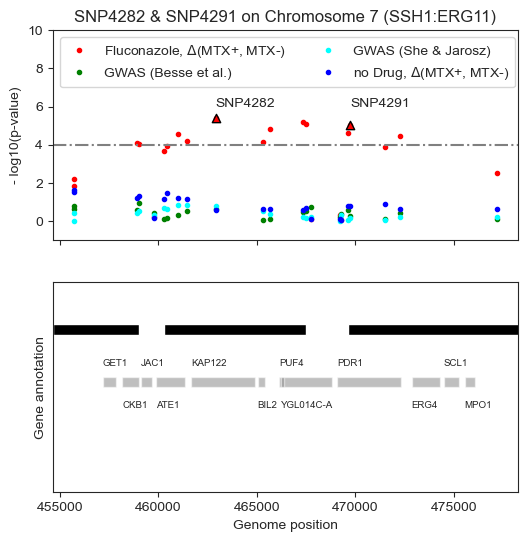

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [60]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

sns.set_style('ticks')


# Set locus region
locus_chromosome = 7
lead_SNP_1 = 4291
lead_SNP_position = 469734
lead_SNP_2 = 4282
lead_SNP_2_position = 462915
LD_block_start = 460296 - 5000
LD_block_end = 472298 + 5000

eqtl_matrix_results = pd.read_csv('../../../results/04_eQTL_matrix/piQTL_june2024_pval_results.txt', sep='\t')
PPI = 'SSH1_ERG11'
DRUG = 'Fluconazole'

Fluc_piQTLs = eqtl_matrix_results[eqtl_matrix_results['gene'].str.contains(f'{PPI}_MTX_{DRUG}')].merge(snps_annotations, on='SNP')
noDrug = eqtl_matrix_results[eqtl_matrix_results['gene'].str.contains(f'{PPI}_MTX_noDrug')].merge(snps_annotations, on='SNP')

Fluc_piQTLs = Fluc_piQTLs[~Fluc_piQTLs['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)
noDrug = noDrug[~noDrug['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)


# Subset data to locus region
subset_data1 = Fluc_piQTLs[(Fluc_piQTLs['CHR'] == locus_chromosome) & (Fluc_piQTLs['position'] >= LD_block_start) & (Fluc_piQTLs['position'] <= LD_block_end)]
subset_data1['-log10_P'] = -1 * np.log10(subset_data1['p-value'])

subset_data2 = noDrug[(noDrug['CHR'] == locus_chromosome) & (noDrug['position'] >= LD_block_start) & (noDrug['position'] <= LD_block_end)]
subset_data2['-log10_P'] = -1 * np.log10(subset_data2['p-value'])

subset_data3 = GWAS_Fluconazole_36H[(GWAS_Fluconazole_36H['CHR'] == locus_chromosome) & (GWAS_Fluconazole_36H['BP'] >= LD_block_start) & (GWAS_Fluconazole_36H['BP'] <= LD_block_end)]
subset_data3['-log10_P'] = -1 * np.log10(subset_data3['P'])

subset_data4 = GWAS_Fluconazole_36H_full[(GWAS_Fluconazole_36H_full['CHR'] == locus_chromosome) & (GWAS_Fluconazole_36H_full['BP'] >= LD_block_start) & (GWAS_Fluconazole_36H_full['BP'] <= LD_block_end)]
subset_data4['-log10_P'] = -1 * np.log10(subset_data4['P'])

piQTL_1 = Fluc_piQTLs[Fluc_piQTLs['SNP'] == lead_SNP_1].reset_index(drop=True)
piQTL_2 = Fluc_piQTLs[Fluc_piQTLs['SNP'] == lead_SNP_2].reset_index(drop=True)
piQTL_1['-log10_P'] = - 1 * np.log10(piQTL_1['p-value'])
piQTL_2['-log10_P'] = - 1 * np.log10(piQTL_2['p-value'])


# Plot Manhattan plot
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6, 6), sharex=True)

ax1.scatter(subset_data1['position'], subset_data1['-log10_P'], marker='.', color='red')
ax1.scatter(piQTL_1['position'], piQTL_1['-log10_P'], color='red', marker='^', edgecolor='black')
ax1.annotate(f'SNP{lead_SNP_1}', (lead_SNP_position, 0.5), xytext=(lead_SNP_position, 6), xycoords='data', size=10)
ax1.scatter(piQTL_2['position'], piQTL_2['-log10_P'], color='red', marker='^', edgecolor='black')
ax1.annotate(f'SNP{lead_SNP_2}', (lead_SNP_2_position, 0.5), xytext=(lead_SNP_2_position, 6), xycoords='data', size=10)

ax1.scatter(subset_data4['BP'], subset_data4['-log10_P'], marker='.', color='green')

ax1.scatter(subset_data3['BP'], subset_data3['-log10_P'], marker='.', color='cyan')

ax1.scatter(subset_data2['position'], subset_data2['-log10_P'], marker='.', color='blue')

ax1.axhline(y=4, linestyle='-.', color='grey')
ax1.set_ylim([-1,10])
ax1.set_ylabel('- log10(p-value)')
ax1.set_title(f'SNP{lead_SNP_2} & SNP{lead_SNP_1} on Chromosome {locus_chromosome} ({PPI.replace("_",":")})')

genes = gene_annotations[(gene_annotations['Chrom'] == str(locus_chromosome)) & (gene_annotations['Start'] >= LD_block_start) & (gene_annotations['End'] <= LD_block_end)]
LDs = LD_blocks[(LD_blocks['seqid'] == locus_chromosome) & ((LD_blocks['start'] >= LD_block_start) | (LD_blocks['end'] <= LD_block_end))]
CUTs = CUT_annotations[(CUT_annotations['seqid'] == locus_chromosome) & (CUT_annotations['start'] >= LD_block_start) & (CUT_annotations['end'] <= LD_block_end)]
SUTs = SUT_annotations[(SUT_annotations['seqid'] == locus_chromosome) & (SUT_annotations['start'] >= LD_block_start) & (SUT_annotations['end'] <= LD_block_end)]
XUTs = XUT_annotations[(XUT_annotations['seqid'] == locus_chromosome) & (XUT_annotations['start'] >= LD_block_start) & (XUT_annotations['end'] <= LD_block_end)]


# Extract gene information
for idx in genes.index : 
    chrom = int(genes['Chrom'][idx])
    start = int(genes['Start'][idx])
    end = int(genes['End'][idx])
    gene = genes['Gene'][idx]
    strand = 1

    # Create a FeatureLocation object for the gene
    gene_location = FeatureLocation(start, end, strand=strand)

    # Calculate gene length
    gene_length = len(gene_location)

    # Add gene annotation to the second subplot
    ax2.add_patch(plt.Rectangle((start, 0.5), gene_length, 0.05, facecolor="gray", alpha=0.5))
    if idx % 2 == 0 : 
        ax2.annotate(gene, (start, 0.5), xytext=(start+1,0.6), xycoords='data', size=7)
    else : 
        ax2.annotate(gene, (start, 0.5), xytext=(start,0.4), xycoords='data', size=7)

for idx in LDs.index : 
    chrom = int(LDs['seqid'][idx]) # .split('_')[1]
    start = int(LDs['start'][idx])
    end = int(LDs['end'][idx])

    strand = 1

    # Create a FeatureLocation object for the gene
    gene_location = FeatureLocation(start, end, strand=strand)

    # Calculate gene length
    gene_length = len(gene_location)

    ax2.add_patch(plt.Rectangle((start, 0.75), gene_length, 0.05, facecolor="black"))

for idx in CUTs.index : 
    chrom = int(CUTs['seqid'][idx])
    start = int(CUTs['start'][idx])
    end = int(CUTs['end'][idx])
    strand = CUTs['strand'][idx]
    cut =  CUTs['locus_id'][idx]
    if strand == '+' :
        strand = 1 
    else : 
        strand = -1

    # Create a FeatureLocation object for the gene
    gene_location = FeatureLocation(start, end, strand=strand)

    # Calculate gene length
    gene_length = len(gene_location)

    if strand == 1:
        ax2.add_patch(plt.Arrow(start, 0.25, gene_length, 0, 0.2, facecolor="grey"))
    else : 
        ax2.add_patch(plt.Arrow(start, 0.25, - gene_length, 0, 0.2, facecolor="grey"))
    ax2.annotate(cut, (start, 0.25), xytext=(start,0.30) , xycoords='data', size=7)


for idx in SUTs.index : 
    chrom = int(SUTs['seqid'][idx])
    start = int(SUTs['start'][idx])
    end = int(SUTs['end'][idx])
    strand = SUTs['strand'][idx]
    sut =  SUTs['locus_id'][idx]
    if strand == '+' :
        strand = 1 
    else : 
        strand = -1

    # Create a FeatureLocation object for the gene
    gene_location = FeatureLocation(start, end, strand=strand)

    # Calculate gene length
    gene_length = len(gene_location)

    if strand == 1:
        ax2.add_patch(plt.Arrow(start, 0.15, gene_length, 0, 0.2, facecolor="grey"))
    else : 
        ax2.add_patch(plt.Arrow(start, 0.15, - gene_length, 0, 0.2, facecolor="grey"))
    ax2.annotate(sut, (start, 0.25), xytext=(start,0.20) , xycoords='data', size=7)

for idx in XUTs.index : 
    chrom = int(XUTs['seqid'][idx])
    start = int(XUTs['start'][idx])
    end = int(XUTs['end'][idx])
    strand = XUTs['strand'][idx]
    xut =  XUTs['locus_id'][idx]
    if strand == '+' :
        strand = 1 
    else : 
        strand = -1

    # Create a FeatureLocation object for the gene
    gene_location = FeatureLocation(start, end, strand=strand)

    # Calculate gene length
    gene_length = len(gene_location)

    if strand == 1:
        ax2.add_patch(plt.Arrow(start, 0.05, gene_length, 0, 0.2, facecolor="grey"))
    else : 
        ax2.add_patch(plt.Arrow(start, 0.05, - gene_length, 0, 0.2, facecolor="grey"))
    ax2.annotate(xut, (start, 0.25), xytext=(start,0.10) , xycoords='data', size=7)


# Set x-axis limits and labels for the second subplot
ax2.set_xlabel("Genome position")
ax2.set_ylabel("Gene annotation")

ax2.set_yticks([])
ax2.set_yticklabels([])

custom = [Line2D([], [], marker='.', color='red', linestyle='None'),
        Line2D([], [], marker='.', color='green', linestyle='None'),
        Line2D([], [], marker='.', color='cyan', linestyle='None'),
        Line2D([], [], marker='.', color='blue', linestyle='None')
]

ax1.legend(custom, ['Fluconazole, $\Delta$(MTX+, MTX-)', 'GWAS (Besse et al.)', 'GWAS (She & Jarosz)', 'no Drug, $\Delta$(MTX+, MTX-)'], loc='upper left', ncol=2) 

plt.show()

fig.savefig(f'../../../figures/figure_2/Fluconazole-piQTL_example_{PPI}_{lead_SNP_2}-{lead_SNP_1}_LD_050.eps', dpi=300)
# fig.savefig(f'../../../figures/figure_2/Fluconazole-piQTL_example_{PPI}_{lead_SNP_2}-{lead_SNP_1}_LD_050.pdf', dpi=300)


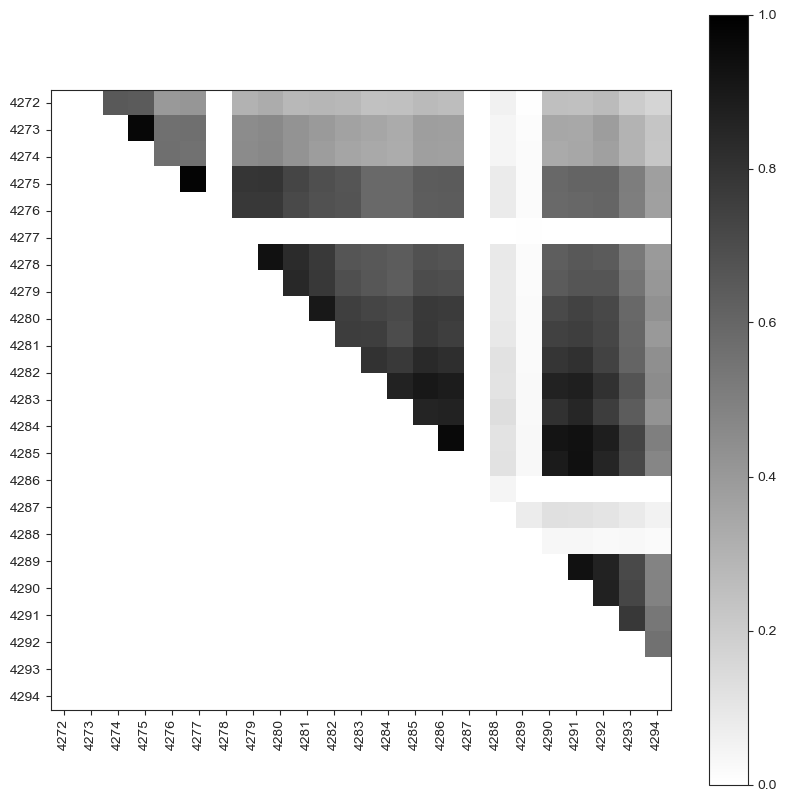

In [61]:
# Extract a subset of the LD table
SS = LD_table[[str(x) for x in range(4271, 4295)]][4271:4295]

# Define the extent of the heatmap such that ticks are at the center of each square
extent = [4271.5, 4294.5, 4294.5, 4271.5]

# Calculate the tick positions
ticks = np.arange(4272, 4295, 1)

# Plot the heatmap
f = plt.figure(figsize=(10, 10))
plt.imshow(SS, vmin=0, vmax=1, extent=extent, cmap='binary', interpolation='none', aspect='equal')

# Add grid lines
# plt.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5)
plt.xticks(ticks, rotation=90)
plt.yticks(ticks)

# Add colorbar
plt.colorbar()

# Show plot
plt.show()

# Save the figure
f.savefig(f'../../../figures/figure_2/Fluconazole-piQTL_example_{PPI}_{lead_SNP_2}-{lead_SNP_1}_LD_0.50_LD_block.eps', dpi=300)
# f.savefig(f'../../../figures/figure_2/Fluconazole-piQTL_example_{PPI}_{lead_SNP_2}-{lead_SNP_1}_LD_0.50_LD_block.pdf', dpi=300)


___

#### Metformin example

In [62]:
DRUG = 'Metformin'
Met_piQTLs = final_piQTLs[final_piQTLs['gene'].str.contains(f'_MTX_{DRUG}')]
noDrug = final_piQTLs[final_piQTLs['gene'].str.contains(f'_MTX_noDrug')]

In [63]:
Met_piQTLs[Met_piQTLs['CHR'] == 13].sort_values(['p-value', 'SNP'])[['SNP', 'CHR', 'position', 'locus_id','gene_locus', 'gene_name', '-log10_P', 'LD_b050', 'DRUG', 'PPI']].head(n=10)

,SNP,CHR,position,locus_id,gene_locus,gene_name,-log10_P,LD_b050,DRUG,PPI
0,8799,13,495175,YMR113W,YMR113W,FOL3,8.205347,8797_8798_8799_8800_8801_8802_8803_8804_8805_8...,Metformin,ERG11_ORM2
2,8792,13,489572,YMR109W,YMR109W,MYO5,7.737817,8749_8750_8751_8752_8753_8754_8755_8756_8757_8...,Metformin,ERG11_ORM2
3,8810,13,505070,tL(CAA)M_NFR/NDR,NaN,NaN,7.517515,8809_8810_8811_8812_8813_8814_8815_8816_8817_8...,Metformin,ERG11_ORM2
46,8795,13,489758,YMR109W,YMR109W,MYO5,5.581992,8794_8795,Metformin,ERG11_ORM2
59,8778,13,463519,tD(GUC)M_NFR/NDR,NaN,NaN,5.418472,8749_8750_8751_8752_8753_8754_8755_8756_8757_8...,Metformin,TPO1_MID2
204,8805,13,501075,YMR116C_NFR/NDR,YMR116C,ASC1,4.735006,8797_8798_8799_8800_8801_8802_8803_8804_8805_8...,Metformin,ERG11_PIS1
222,8802,13,500062,YNCM0026C,NaN,NaN,4.670444,8797_8798_8799_8800_8801_8802_8803_8804_8805_8...,Metformin,ERG11_TPO4
257,8815,13,509480,YMR120C_NFR/NDR,YMR120C,ADE17,4.584870,8809_8810_8811_8812_8813_8814_8815_8816_8817_8...,Metformin,ERG11_TPO4
259,8778,13,463519,tD(GUC)M_NFR/NDR,NaN,NaN,4.581327,8749_8750_8751_8752_8753_8754_8755_8756_8757_8...,Metformin,HNM1_MID2
280,8792,13,489572,YMR109W,YMR109W,MYO5,4.519755,8749_8750_8751_8752_8753_8754_8755_8756_8757_8...,Metformin,ERG11_TPO4


<>:105: SyntaxWarning: invalid escape sequence '\D'
<>:105: SyntaxWarning: invalid escape sequence '\D'
<>:105: SyntaxWarning: invalid escape sequence '\D'
<>:105: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_993895/3574580662.py:105: SyntaxWarning: invalid escape sequence '\D'
  ax1.legend(custom, ['Metformin$, \Delta$(MTX+, MTX-)', 'No drug, $\Delta$(MTX+, MTX-)'], loc='upper left', ncol=2)
/tmp/ipykernel_993895/3574580662.py:105: SyntaxWarning: invalid escape sequence '\D'
  ax1.legend(custom, ['Metformin$, \Delta$(MTX+, MTX-)', 'No drug, $\Delta$(MTX+, MTX-)'], loc='upper left', ncol=2)
/tmp/ipykernel_993895/3574580662.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_data1['-log10_P'] = -1 * np.log10(subset_data1['p-v

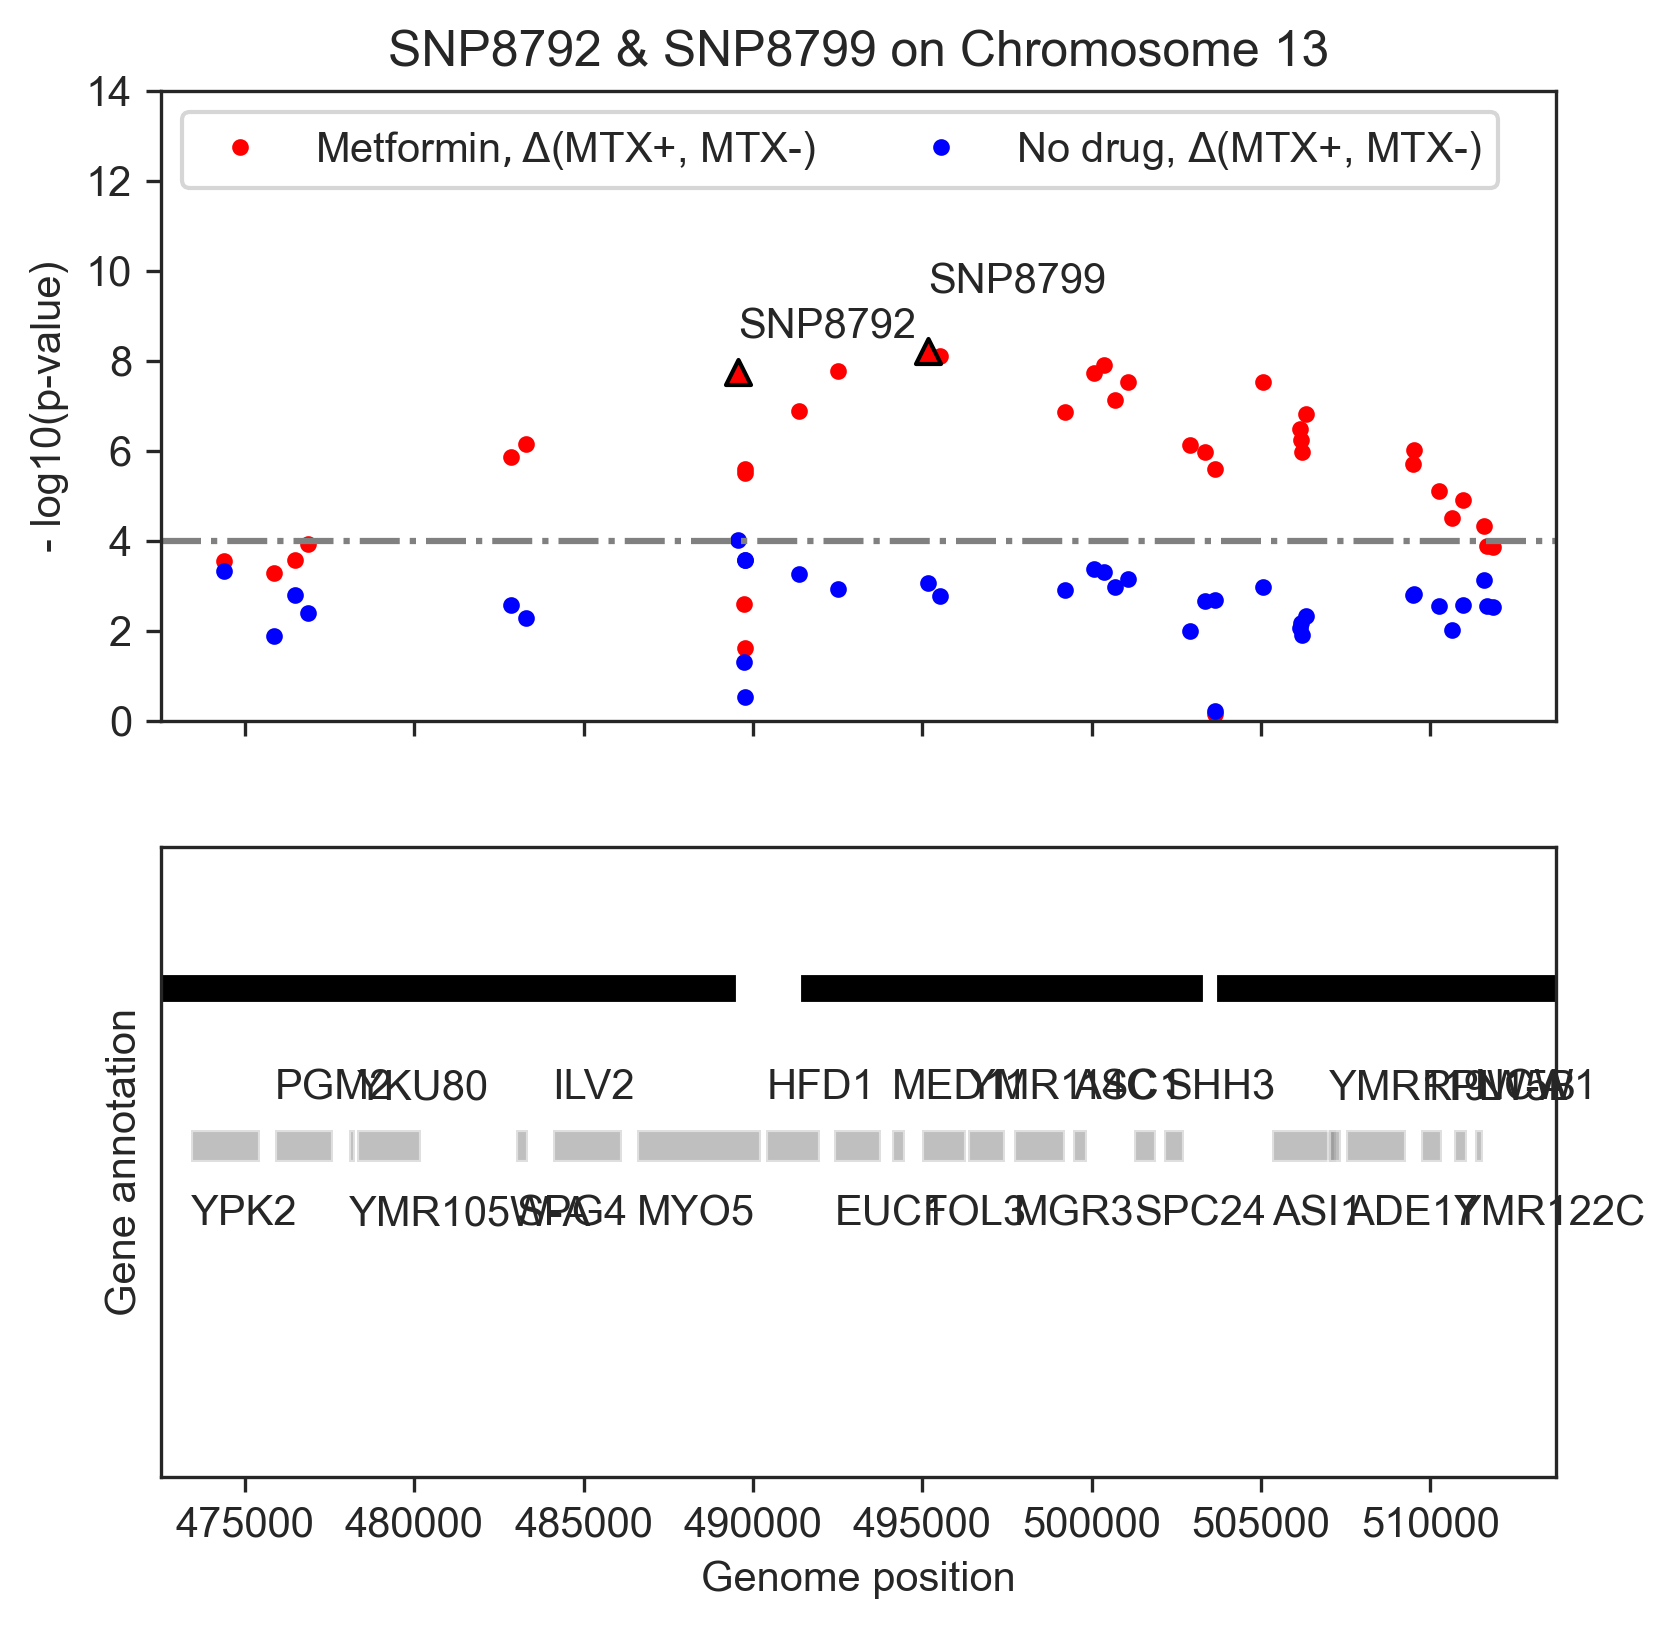

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')

# Set locus region
locus_chromosome = 13
lead_SNP_1 = 8792
lead_SNP_position_1 = 489572
lead_SNP_2 = 8799
lead_SNP_position_2 = 495175
LD_block_start = 483014 - 10000
LD_block_end = 502734 + 10000

eqtl_matrix_results = pd.read_csv('../../../results/04_eQTL_matrix/piQTL_june2024_pval_results.txt', sep='\t')
PPI = 'ERG11_ORM2'
DRUG = 'Metformin'

Metformin_piQTLs = eqtl_matrix_results[eqtl_matrix_results['gene'].str.contains(f'{PPI}_MTX_{DRUG}')].merge(snps_annotations, on='SNP')
noDrug = eqtl_matrix_results[eqtl_matrix_results['gene'].str.contains(f'{PPI}_MTX_noDrug')].merge(snps_annotations, on='SNP')

Metformin_piQTLs = Metformin_piQTLs[~Metformin_piQTLs['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)
noDrug = noDrug[~noDrug['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)


# Subset data() to locus region
subset_data1 = Metformin_piQTLs[(Metformin_piQTLs['CHR'] == locus_chromosome) & (Metformin_piQTLs['position'] >= LD_block_start) & (Metformin_piQTLs['position'] <= LD_block_end) & ~(Metformin_piQTLs['SNP'].isin([lead_SNP_1,lead_SNP_2]))]
subset_data1['-log10_P'] = -1 * np.log10(subset_data1['p-value'])

subset_data2 = noDrug[(noDrug['CHR'] == locus_chromosome) & (noDrug['position'] >= LD_block_start) & (noDrug['position'] <= LD_block_end)].reset_index(drop=True)
subset_data2['-log10_P'] = -1 * np.log10(subset_data2['p-value'])

piQTL_1 = Metformin_piQTLs[Metformin_piQTLs['SNP'] == lead_SNP_1].reset_index(drop=True)
piQTL_2 = Metformin_piQTLs[Metformin_piQTLs['SNP'] == lead_SNP_2].reset_index(drop=True)
piQTL_1['-log10_P'] = - 1 * np.log10(piQTL_1['p-value'])
piQTL_2['-log10_P'] = - 1 * np.log10(piQTL_2['p-value'])


# Plot Manhattan plot
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6, 6), sharex=True, dpi=300)
ax1.scatter(subset_data1['position'], subset_data1['-log10_P'], marker='.', color='red')
ax1.scatter(piQTL_1['position'], piQTL_1['-log10_P'], color='red', marker='^', edgecolor='black')
ax1.scatter(piQTL_2['position'], piQTL_2['-log10_P'], color='red', marker='^', edgecolor='black')

ax1.annotate(f'SNP{lead_SNP_1}', (lead_SNP_position_1, 0.5), xytext=(lead_SNP_position_1-10, 8.5), xycoords='data', size=10)
ax1.annotate(f'SNP{lead_SNP_2}', (lead_SNP_position_2, 0.5), xytext=(lead_SNP_position_2, 9.5), xycoords='data', size=10)

ax1.scatter(subset_data2['position'], subset_data2['-log10_P'], marker='.', color='blue')

ax1.axhline(y=4, linestyle='-.', color='grey')
ax1.set_ylim([0,14])
ax1.set_ylabel('- log10(p-value)')
ax1.set_title(f'SNP{lead_SNP_1} & SNP{lead_SNP_2} on Chromosome {locus_chromosome}')

genes = gene_annotations[(gene_annotations['Chrom'] == str(locus_chromosome)) & (gene_annotations['Start'] >= LD_block_start) & (gene_annotations['End'] <= LD_block_end)]
LDs = LD_blocks[(LD_blocks['seqid'] == locus_chromosome) & ((LD_blocks['start'] >= LD_block_start) | (LD_blocks['end'] <= LD_block_end))]

# Extract gene information
for idx in genes.index : 
    chrom = int(genes['Chrom'][idx])
    start = int(genes['Start'][idx])
    end = int(genes['End'][idx])
    gene = genes['Gene'][idx]
    strand = 1

    # Create a FeatureLocation object for the gene
    gene_location = FeatureLocation(start, end, strand=strand)

    # Calculate gene length
    gene_length = len(gene_location)

    # Add gene annotation to the second subplot
    ax2.add_patch(plt.Rectangle((start, 0.5), gene_length, 0.05, facecolor="gray", alpha=0.5))
    if idx % 2 == 0 : 
        ax2.annotate(gene, (start, 0.5), xytext=(start,0.6) , xycoords='data', size=10)
    else : 
        ax2.annotate(gene, (start, 0.5), xytext=(start,0.4) , xycoords='data', size=10)

for idx in LDs.index : 
    chrom = int(LDs['seqid'][idx])
    start = int(LDs['start'][idx])
    end = int(LDs['end'][idx])
    strand = 1
    # Create a FeatureLocation object for the gene
    gene_location = FeatureLocation(start, end, strand=strand)

    # Calculate gene length
    gene_length = len(gene_location)
    ax2.add_patch(plt.Rectangle((start, 0.75), gene_length, 0.05, facecolor="black"))


# Set x-axis limits and labels for the second subplot
ax2.set_xlabel("Genome position")
ax2.set_ylabel("Gene annotation")

ax2.set_yticks([])
ax2.set_yticklabels([])

custom = [Line2D([], [], marker='.', color='red', linestyle='None'),
          Line2D([], [], marker='.', color='blue', linestyle='None')
]

ax1.legend(custom, ['Metformin$, \Delta$(MTX+, MTX-)', 'No drug, $\Delta$(MTX+, MTX-)'], loc='upper left', ncol=2)

plt.show()

fig.savefig(f'../../../figures/figure_2/Metformin-piQTL_example_{PPI}_{lead_SNP_1}-{lead_SNP_2}_LD_050.eps', dpi=300)
# fig.savefig(f'../../../figures/figure_2/Metformin-piQTL_example_{PPI}_{lead_SNP_1}-{lead_SNP_2}_LD_050.pdf', dpi=300)


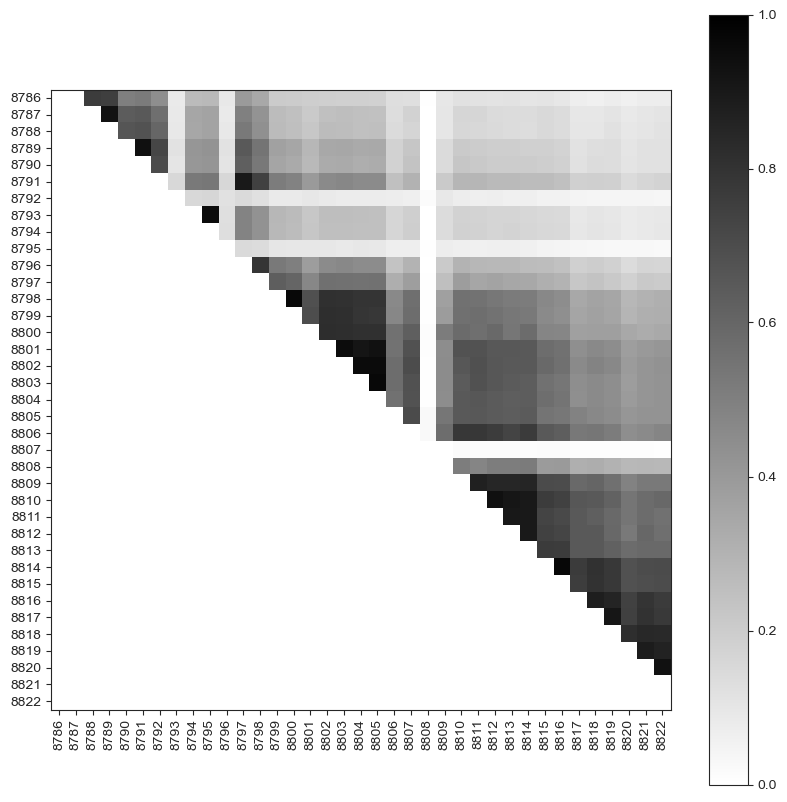

In [65]:
# Extract a subset of the LD table
SS = LD_table[[str(x) for x in range(8786, 8823)]][8786:8823]

# Define the extent of the heatmap such that ticks are at the center of each square
extent = [8785.5, 8822.5, 8822.5, 8785.5]

# Calculate the tick positions
ticks = np.arange(8786, 8823, 1)

# Plot the heatmap
f = plt.figure(figsize=(10, 10))
plt.imshow(SS, vmin=0, vmax=1, extent=extent, cmap='binary', interpolation='none', aspect='equal')

# Add grid lines
# plt.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5)
plt.xticks(ticks, rotation=90)
plt.yticks(ticks)

# Add colorbar
plt.colorbar()

# Show plot
plt.show()

# Save the figure
f.savefig(f'../../../figures/figure_2/Metformin-piQTL_example_{PPI}_{lead_SNP_1}-{lead_SNP_2}_LD_0.50_LD_block.eps', dpi=300)
# f.savefig(f'../../../figures/figure_2/Metformin-piQTL_example_{PPI}_{lead_SNP_1}-{lead_SNP_2}_LD_0.50_LD_block.pdf', dpi=300)


____

## non-coding piQTL example

/tmp/ipykernel_993895/2517209092.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_data1['neg_log10_pval'] = -1 * np.log10(subset_data1['p-value'])
/tmp/ipykernel_993895/2517209092.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_data2['neg_log10_pval'] = -1 * np.log10(subset_data2['p-value'])
/tmp/ipykernel_993895/2517209092.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

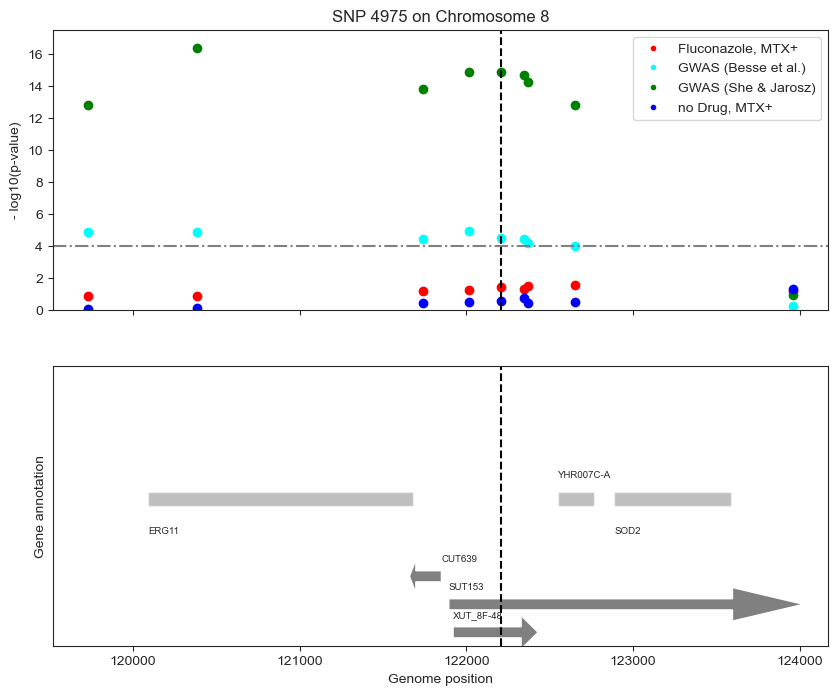

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set locus region
locus_chromosome = 8
locus_start = 122207 - 2500
locus_end = 122207 + 2000

eqtl_matrix_results = pd.read_csv('../../../results/04_eQTL_matrix/piQTL_june2024_pval_results.txt', sep='\t')
PPI = 'SSH1_ERG11'
DRUG = 'Fluconazole'

Fluc_piQTLs = eqtl_matrix_results[eqtl_matrix_results['gene'].str.contains(f'{PPI}_MTX_{DRUG}')].merge(snps_annotations, on='SNP')
noDrug = eqtl_matrix_results[eqtl_matrix_results['gene'].str.contains(f'{PPI}_MTX_noDrug')].merge(snps_annotations, on='SNP')

Fluc_piQTLs = Fluc_piQTLs[~Fluc_piQTLs['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)
noDrug = noDrug[~noDrug['SNP'].isin(all_SNPs_to_mask)].reset_index(drop=True)

# Subset data to locus region
subset_data1 = Fluc_piQTLs[(Fluc_piQTLs['CHR'] == locus_chromosome) & (Fluc_piQTLs['position'] >= locus_start) & (Fluc_piQTLs['position'] <= locus_end)]
subset_data1['neg_log10_pval'] = -1 * np.log10(subset_data1['p-value'])

subset_data2 = noDrug[(noDrug['CHR'] == locus_chromosome) & (noDrug['position'] >= locus_start) & (noDrug['position'] <= locus_end)]
subset_data2['neg_log10_pval'] = -1 * np.log10(subset_data2['p-value'])

subset_data3 = GWAS_Fluconazole_36H[(GWAS_Fluconazole_36H['CHR'] == locus_chromosome) & (GWAS_Fluconazole_36H['BP'] >= locus_start) & (GWAS_Fluconazole_36H['BP'] <= locus_end)]
subset_data3['neg_log10_pval'] = -1 * np.log10(subset_data3['P'])

subset_data4 = GWAS_Fluconazole_36H_full[(GWAS_Fluconazole_36H_full['CHR'] == locus_chromosome) & (GWAS_Fluconazole_36H_full['BP'] >= locus_start) & (GWAS_Fluconazole_36H_full['BP'] <= locus_end)]
subset_data4['neg_log10_pval'] = -1 * np.log10(subset_data4['P'])


# Plot Manhattan plot
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
ax1.scatter(subset_data1['position'], subset_data1['neg_log10_pval'], color='red')

ax1.scatter(subset_data4['BP'], subset_data4['neg_log10_pval'], color='green')
ax1.scatter(subset_data3['BP'], subset_data3['neg_log10_pval'], color='cyan')

ax1.scatter(subset_data2['position'], subset_data2['neg_log10_pval'], color='blue')


ax1.axvline(x=122207, linestyle='--', color='black')
ax1.axhline(y=4, linestyle='-.', color='grey')
ax1.set_ylim([0,17.5])
ax1.set_ylabel('- log10(p-value)')
ax1.set_title('SNP 4975 on Chromosome 8')


ax2.axvline(x=122207, linestyle='--', color='black')
genes = gene_annotations[(gene_annotations['Chrom'] == '8') & (gene_annotations['Start'] >= locus_start) & (gene_annotations['End'] <= locus_end)]
LDs = LD_blocks[(LD_blocks['seqid'] == locus_chromosome) & (LD_blocks['start'] >= locus_start) & (LD_blocks['end'] <= locus_end)]
CUTs = CUT_annotations[(CUT_annotations['seqid'] == locus_chromosome) & (CUT_annotations['start'] >= locus_start) & (CUT_annotations['end'] <= locus_end)]
SUTs = SUT_annotations[(SUT_annotations['seqid'] == locus_chromosome) & (SUT_annotations['start'] >= locus_start) & (SUT_annotations['end'] <= locus_end)]
XUTs = XUT_annotations[(XUT_annotations['seqid'] == locus_chromosome) & (XUT_annotations['start'] >= locus_start) & (XUT_annotations['end'] <= locus_end)]


# Extract gene information
for idx in genes.index : 
    chrom = int(genes['Chrom'][idx])
    start = int(genes['Start'][idx])
    end = int(genes['End'][idx])
    gene = genes['Gene'][idx]
    strand = 1

    # Create a FeatureLocation object for the gene
    gene_location = FeatureLocation(start, end, strand=strand)

    # Calculate gene length
    gene_length = len(gene_location)

    # Add gene annotation to the second subplot
    ax2.add_patch(plt.Rectangle((start, 0.5), gene_length, 0.05, facecolor="gray", alpha=0.5))
    if idx % 2 == 0 : 
        ax2.annotate(gene, (start, 0.5), xytext=(start,0.6) , xycoords='data', size=7)
    else : 
        ax2.annotate(gene, (start, 0.5), xytext=(start,0.4) , xycoords='data', size=7)

for idx in LDs.index : 
    chrom = int(LDs['seqid'][idx])
    start = int(LDs['start'][idx])
    end = int(LDs['end'][idx])

    strand = 1

    # Create a FeatureLocation object for the gene
    gene_location = FeatureLocation(start, end, strand=strand)

    # Calculate gene length
    gene_length = len(gene_location)

    ax2.add_patch(plt.Rectangle((start, 0.75), gene_length, 0.05, facecolor="black"))

for idx in CUTs.index : 
    chrom = int(CUTs['seqid'][idx])
    start = int(CUTs['start'][idx])
    end = int(CUTs['end'][idx])
    strand = CUTs['strand'][idx]
    cut =  CUTs['locus_id'][idx]
    if strand == '+' :
        strand = 1 
    else : 
        strand = -1

    # Create a FeatureLocation object for the gene
    gene_location = FeatureLocation(start, end, strand=strand)

    # Calculate gene length
    gene_length = len(gene_location)

    if strand == 1:
        ax2.add_patch(plt.Arrow(start, 0.25, gene_length, 0, width=0.2, facecolor="grey"))
    else : 
        ax2.add_patch(plt.Arrow(start, 0.25, -gene_length, 0, width=0.2, facecolor="grey"))
    ax2.annotate(cut, (start, 0.25), xytext=(start,0.30) , xycoords='data', size=7)


for idx in SUTs.index : 
    chrom = int(SUTs['seqid'][idx])
    start = int(SUTs['start'][idx])
    end = int(SUTs['end'][idx])
    strand = SUTs['strand'][idx]
    sut =  SUTs['locus_id'][idx]
    if strand == '+' :
        strand = 1 
    else : 
        strand = -1

    # Create a FeatureLocation object for the gene
    gene_location = FeatureLocation(start, end, strand=strand)

    # Calculate gene length
    gene_length = len(gene_location)

    if strand == 1:
        ax2.add_patch(plt.Arrow(start, 0.15, gene_length, 0, width=0.2, facecolor="grey"))
    else : 
        ax2.add_patch(plt.Arrow(start, 0.15, - gene_length, 0, width=0.2, facecolor="grey"))
    ax2.annotate(sut, (start, 0.25), xytext=(start,0.20) , xycoords='data', size=7)

for idx in XUTs.index : 
    chrom = int(XUTs['seqid'][idx])
    start = int(XUTs['start'][idx])
    end = int(XUTs['end'][idx])
    strand = XUTs['strand'][idx]
    xut =  XUTs['locus_id'][idx]
    if strand == '+' :
        strand = 1 
    else : 
        strand = -1

    # Create a FeatureLocation object for the gene
    gene_location = FeatureLocation(start, end, strand=strand)

    # Calculate gene length
    gene_length = len(gene_location)

    if strand == 1:
        ax2.add_patch(plt.Arrow(start, 0.05, gene_length, 0, width=0.2, facecolor="grey"))
    else : 
        ax2.add_patch(plt.Arrow(start, 0.05, - gene_length, 0, width=0.2, facecolor="grey"))
    ax2.annotate(xut, (start, 0.25), xytext=(start,0.10) , xycoords='data', size=7)


# Set x-axis limits and labels for the second subplot
ax2.set_xlabel("Genome position")
ax2.set_ylabel("Gene annotation")

ax2.set_yticks([])
ax2.set_yticklabels([])

custom = [Line2D([], [], marker='.', color='red', linestyle='None'),
        Line2D([], [], marker='.', color='cyan', linestyle='None'),
        Line2D([], [], marker='.', color='green', linestyle='None'),
        Line2D([], [], marker='.', color='blue', linestyle='None')
]

ax1.legend(custom, ['Fluconazole, MTX+', 'GWAS (Besse et al.)', 'GWAS (She & Jarosz)', 'no Drug, MTX+'], loc='upper right')

plt.show()

fig.savefig('../../../figures/figure_5/cis-piQTL_UTs_zoom.eps', dpi=300)
